In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cohen's Kappa Calculation

In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

# 1. Load the two annotation files
df1 = pd.read_csv('/path/to/annotation_samples_150.csv')
df2 = pd.read_csv('/path/to/annotation_samples_50.csv')

match_keys = ['conv_id', 'subject_id', 'object_id', 'relation']

# 3. Merge the dataframes
merged_df = pd.merge(
    df1,
    df2,
    on=match_keys,
    suffixes=('_annotator1', '_annotator2')
)

# 4. Extract the human labels
y1 = merged_df['manual_label_annotator1']
y2 = merged_df['manual_label_annotator2']

# 5. Calculate Cohen's Kappa
kappa = cohen_kappa_score(y1, y2)

print(f"✅ Successfully matched {len(merged_df)} out of 50 samples.")
print(f"📊 Cohen's Kappa Inter-rater Agreement: {kappa:.4f}")

# 6. Simple interpretation for your paper
if kappa > 0.40:
    print("Interpretation: Moderate Agreement (Standard for social sentiment tasks)")
else:
    print("Interpretation: Fair/Slight Agreement")

✅ Successfully matched 50 out of 50 samples.
📊 Cohen's Kappa Inter-rater Agreement: 0.5798
Interpretation: Moderate Agreement (Standard for social sentiment tasks)


In [ ]:
print("df1 head:")
display(df1.head())

print("\ndf2 head:")
display(df2.head())

print("\ndf_merged head:")
display(merged_df.head())

df1 head:


,conv_id,sentence,manual_label,subject_id,object_id,relation,subject_name,object_name,context_length
0,156,"(-1 Turn: Speaker 2: Uh, y’know, starve a feve...",negative,156_Spkr_4,156_Spkr_2,per:friends,Speaker 4,Speaker 2,257
1,75,(-1 Turn: Speaker 2: No.) (Target Turn: Speake...,neutral,Chandler,75_Spkr_1,per:friends,Chandler,Speaker 1,302
2,224,(-1 Turn: Speaker 1: You've got to get back ou...,negative,224_Spkr_2,224_Spkr_1,per:friends,Speaker 2,Speaker 1,194
3,241,(-1 Turn: N/A) (Target Turn: Speaker 1: Hey.) ...,neutral,241_Spkr_1,241_Spkr_2,per:friends,Speaker 1,Speaker 2,95
4,19,(-1 Turn: Speaker 1: Presenting the award for ...,positive,Rachel,19_Spkr_2,per:friends,Rachel,Speaker 2,818



df2 head:


,conv_id,sentence,manual_label,subject_id,object_id,relation,subject_name,object_name,context_length
0,311,(-1 Turn: Speaker 2: You like the Purple Rain ...,positive,311_Spkr_4,311_Spkr_2,per:subordinate,Speaker 4,Speaker 2,174
1,197,"(-1 Turn: Speaker 3: Oh, uh, I... don't... car...",positive,197_Spkr_4,197_Spkr_5,per:positive_impression,Speaker 4,Speaker 5,251
2,130,"(-1 Turn: Speaker 1: Sure, sure. What's with t...",neutral,130_Spkr_3,130_Spkr_1,per:boss,Speaker 3,Speaker 1,191
3,282,(-1 Turn: N/A) (Target Turn: Speaker 1: OK.) (...,neutral,282_Spkr_1,Frank,per:parents,Speaker 1,Frank,84
4,341,(-1 Turn: Speaker 2: Really?!) (Target Turn: S...,positive,Monica,Mr. Geller,per:parents,Monica,Mr. Geller,429



df_merged head:


,conv_id,sentence_annotator1,manual_label_annotator1,subject_id,object_id,relation,subject_name_annotator1,object_name_annotator1,context_length_annotator1,sentence_annotator2,manual_label_annotator2,subject_name_annotator2,object_name_annotator2,context_length_annotator2
0,19,(-1 Turn: Speaker 1: Presenting the award for ...,positive,Rachel,19_Spkr_2,per:friends,Rachel,Speaker 2,818,(-1 Turn: Speaker 1: Presenting the award for ...,positive,Rachel,Speaker 2,818
1,156,(-1 Turn: Speaker 1: Monica! Chandler! I’m rea...,neutral,156_Spkr_2,156_Spkr_3,per:friends,Speaker 2,Speaker 3,245,(-1 Turn: Speaker 1: Monica! Chandler! I’m rea...,neutral,Speaker 2,Speaker 3,245
2,108,(-1 Turn: N/A) (Target Turn: Speaker 1: Goodni...,positive,108_Spkr_1,Joey,per:friends,Speaker 1,Joey,101,(-1 Turn: N/A) (Target Turn: Speaker 1: Goodni...,neutral,Speaker 1,Joey,101
3,61,(-1 Turn: Speaker 1: So weird to see all these...,neutral,61_Spkr_2,John Rosoff,per:friends,Speaker 2,John Rosoff,263,(-1 Turn: Speaker 1: So weird to see all these...,neutral,Speaker 2,John Rosoff,263
4,132,(-1 Turn: N/A) (Target Turn: Speaker 1: Oh tha...,positive,Joey,132_Spkr_1,per:friends,Joey,Speaker 1,161,(-1 Turn: N/A) (Target Turn: Speaker 1: Oh tha...,positive,Joey,Speaker 1,161


## Confusion Matrix

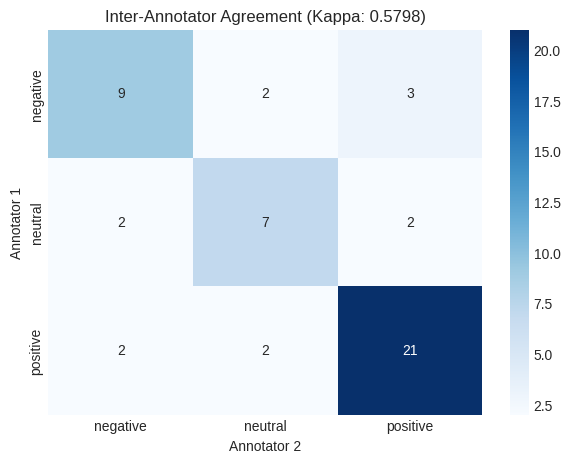

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Create the confusion matrix
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y1, y2, labels=labels)

# 2. Plotting
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Annotator 2')
plt.ylabel('Annotator 1')
plt.title(f'Inter-Annotator Agreement (Kappa: {kappa:.4f})')
plt.savefig('agreement_matrix.png')

In [ ]:
print(f"📊 Cohen's Kappa Inter-rater Agreement: {kappa:.4f}")

# Simple interpretation
if kappa > 0.40:
    print("Interpretation: Moderate Agreement (Standard for social sentiment tasks)")
elif kappa > 0.20:
    print("Interpretation: Fair Agreement")
else:
    print("Interpretation: Slight Agreement")

📊 Cohen's Kappa Inter-rater Agreement: 0.5798
Interpretation: Moderate Agreement (Standard for social sentiment tasks)


### 4. Visualizations


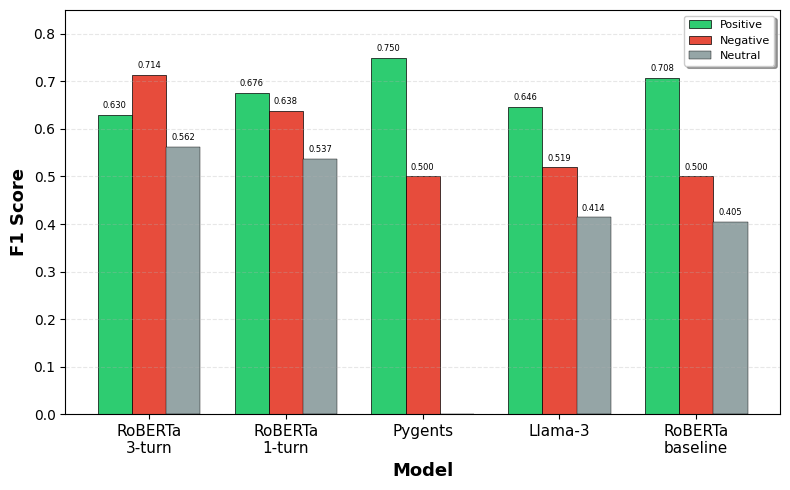

In [7]:
import matplotlib.pyplot as plt
import numpy as np

models = ['RoBERTa\n3-turn', 'RoBERTa\n1-turn', 'Pygents', 'Llama-3', 'RoBERTa\nbaseline']
positive = [0.630, 0.676, 0.750, 0.646, 0.708]
negative = [0.714, 0.638, 0.500, 0.519, 0.500]
neutral = [0.562, 0.537, None, 0.414, 0.405]  # Pygents has no neutral

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, positive, width, label='Positive', color='#2ecc71', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, negative, width, label='Negative', color='#e74c3c', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, [n if n else 0 for n in neutral], width,
               label='Neutral', color='#95a5a6', edgecolor='black', linewidth=0.3)

ax.set_ylabel('F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=8, frameon=True, shadow=True)
ax.set_ylim(0, 0.85)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.savefig('per_class_f1_comparison.pdf', dpi=250, bbox_inches='tight')
plt.show()

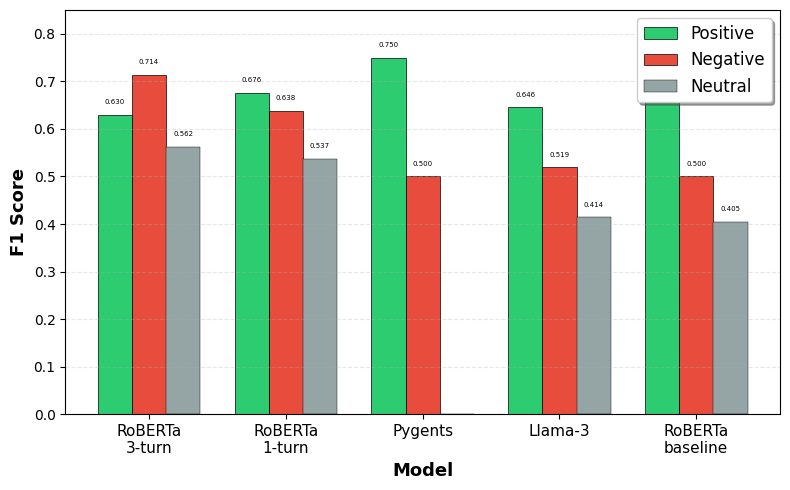

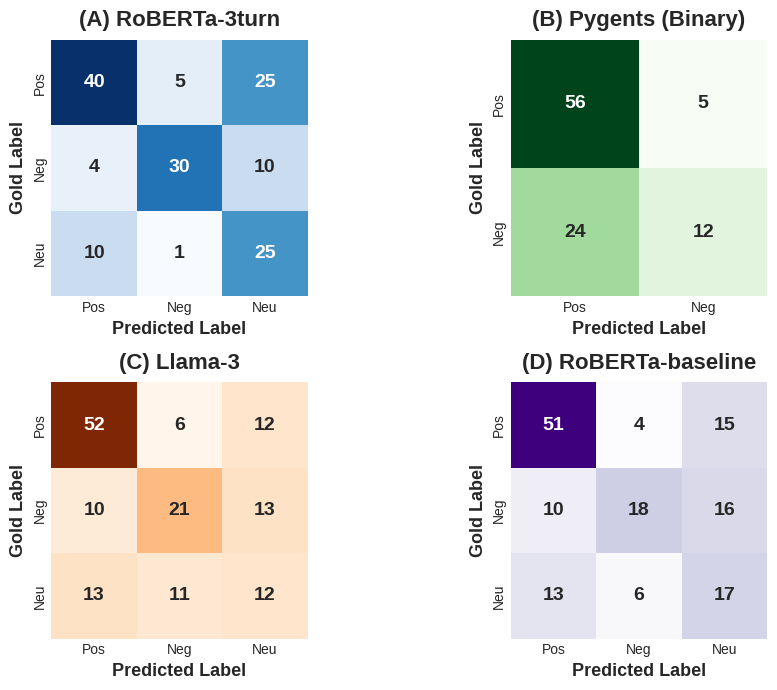

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define confusion matrices based on your results
cm_roberta_3turn = np.array([
    [40, 5, 25],
    [4, 30, 10],
    [10, 1, 25]
])

cm_pygents = np.array([
    [56, 5],
    [24, 12]
])

cm_llama3 = np.array([
    [52, 6, 12],
    [10, 21, 13],
    [13, 11, 12]
])

cm_baseline = np.array([
    [51, 4, 15],
    [10, 18, 16],
    [13, 6, 17]
])

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# RoBERTa-3turn
sns.heatmap(cm_roberta_3turn, annot=True, fmt='d', cmap='Blues',
            ax=axes[0,0], cbar=False, square=True,
            xticklabels=['Pos', 'Neg', 'Neu'],
            yticklabels=['Pos', 'Neg', 'Neu'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0,0].set_title('(A) RoBERTa-3turn', fontsize=16, fontweight='bold', pad=10)
axes[0,0].set_ylabel('Gold Label', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

# Pygents
sns.heatmap(cm_pygents, annot=True, fmt='d', cmap='Greens',
            ax=axes[0,1], cbar=False, square=True,
            xticklabels=['Pos', 'Neg'],
            yticklabels=['Pos', 'Neg'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0,1].set_title('(B) Pygents (Binary)', fontsize=16, fontweight='bold', pad=10)
axes[0,1].set_ylabel('Gold Label', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

# Llama-3
sns.heatmap(cm_llama3, annot=True, fmt='d', cmap='Oranges',
            ax=axes[1,0], cbar=False, square=True,
            xticklabels=['Pos', 'Neg', 'Neu'],
            yticklabels=['Pos', 'Neg', 'Neu'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1,0].set_title('(C) Llama-3', fontsize=16, fontweight='bold', pad=10)
axes[1,0].set_ylabel('Gold Label', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

# RoBERTa-baseline
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Purples',
            ax=axes[1,1], cbar=False, square=True,
            xticklabels=['Pos', 'Neg', 'Neu'],
            yticklabels=['Pos', 'Neg', 'Neu'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1,1].set_title('(D) RoBERTa-baseline', fontsize=16, fontweight='bold', pad=10)
axes[1,1].set_ylabel('Gold Label', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.pdf', dpi=300, bbox_inches='tight')
plt.show()

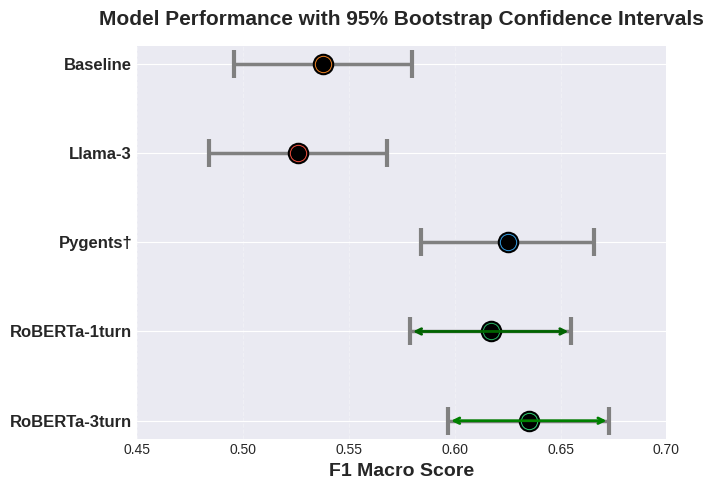

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['RoBERTa-3turn', 'RoBERTa-1turn', 'Pygents†', 'Llama-3', 'Baseline']
f1_scores = [0.635, 0.617, 0.625, 0.526, 0.538]
lower_ci = [0.597, 0.579, 0.584, 0.484, 0.496]
upper_ci = [0.673, 0.655, 0.666, 0.568, 0.580]

errors = [
    [f1_scores[i] - lower_ci[i], upper_ci[i] - f1_scores[i]]
    for i in range(len(models))
]
errors = np.array(errors).T

fig, ax = plt.subplots(figsize=(7, 5))

# Color code by performance tier
colors = ['#2ecc71', '#27ae60', '#3498db', '#e74c3c', '#e67e22']

ax.errorbar(f1_scores, range(len(models)), xerr=errors,
            fmt='o', markersize=10, capsize=10, capthick=3,
            color='black', ecolor='gray', elinewidth=2.5)

# Color the markers
for i, (x, y, c) in enumerate(zip(f1_scores, range(len(models)), colors)):
    ax.plot(x, y, 'o', markersize=14, color=c, markeredgecolor='black', markeredgewidth=1.5)

ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=12, fontweight='bold')
ax.set_xlabel('F1 Macro Score', fontsize=14, fontweight='bold')
ax.set_title('Model Performance with 95% Bootstrap Confidence Intervals',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim(0.45, 0.70)

# Add overlap annotation
ax.annotate('', xy=(0.597, 0), xytext=(0.673, 0),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))

ax.annotate('', xy=(0.579, 1), xytext=(0.655, 1),
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2))

plt.tight_layout()
plt.savefig('bootstrap_ci_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()
